In [164]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from typing import Annotated

import numpy as np

from geneticengine.grammar.metahandlers.ints import IntRange
from geneticengine.grammar import extract_grammar
from geneticengine.problems import SingleObjectiveProblem, MultiObjectiveProblem
from geneticengine.random.sources import NativeRandomSource
from geneticengine.algorithms.gp.gp import GeneticProgramming
from geneticengine.evaluation.budget import TimeBudget, EvaluationBudget
from geneticengine.representations.tree.initializations import MaxDepthDecider
from geneticengine.representations.tree.treebased import TreeBasedRepresentation
from geneticengine.evaluation.recorder import CSVSearchRecorder
from geneticengine.evaluation.tracker import ProgressTracker

from geneticengine.algorithms.gp.operators.combinators import ParallelStep, SequenceStep
from geneticengine.algorithms.gp.operators.crossover import GenericCrossoverStep
from geneticengine.algorithms.gp.operators.elitism import ElitismStep
from geneticengine.algorithms.gp.operators.mutation import GenericMutationStep
from geneticengine.algorithms.gp.operators.novelty import NoveltyStep
from geneticengine.algorithms.gp.operators.selection import LexicaseSelection, TournamentSelection

from sklearn.datasets import load_breast_cancer

import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


import time

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('creaditcard_small_10.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28480 entries, 0 to 28479
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      28480 non-null  float64
 1   V2      28480 non-null  float64
 2   V3      28480 non-null  float64
 3   V4      28480 non-null  float64
 4   V5      28480 non-null  float64
 5   V6      28480 non-null  float64
 6   V7      28480 non-null  float64
 7   V8      28480 non-null  float64
 8   V9      28480 non-null  float64
 9   V10     28480 non-null  float64
 10  V11     28480 non-null  float64
 11  V12     28480 non-null  float64
 12  V13     28480 non-null  float64
 13  V14     28480 non-null  float64
 14  V15     28480 non-null  float64
 15  V16     28480 non-null  float64
 16  V17     28480 non-null  float64
 17  V18     28480 non-null  float64
 18  V19     28480 non-null  float64
 19  V20     28480 non-null  float64
 20  V21     28480 non-null  float64
 21  V22     28480 non-null  float64
 22

In [166]:
target_var = 'Class'

split_percentage = 0.8
split_point = int(len(df) * split_percentage)

train_df = df.iloc[:split_point]
test_df = df.iloc[split_point:]

X_train = train_df.drop(target_var, axis=1)
y_train = train_df[target_var]
X_test = test_df.drop(target_var, axis=1)
y_test = test_df[target_var]

In [167]:
scaler = StandardScaler()
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])

In [168]:
feature_names = X_train.columns.tolist()
n_features = len(feature_names)

In [169]:
y_train.value_counts()

Class
0    22698
1       86
Name: count, dtype: int64

In [170]:
# baseline_model = DecisionTreeClassifier(random_state=42)
baseline_model = RandomForestClassifier(random_state=42)

baseline_model.fit(X_train, y_train)

baseline_y_pred = baseline_model.predict(X_test)

baseline_f1 = f1_score(y_test, baseline_y_pred)

print(baseline_f1)

0.6


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5689
           1       1.00      0.43      0.60         7

    accuracy                           1.00      5696
   macro avg       1.00      0.71      0.80      5696
weighted avg       1.00      1.00      1.00      5696



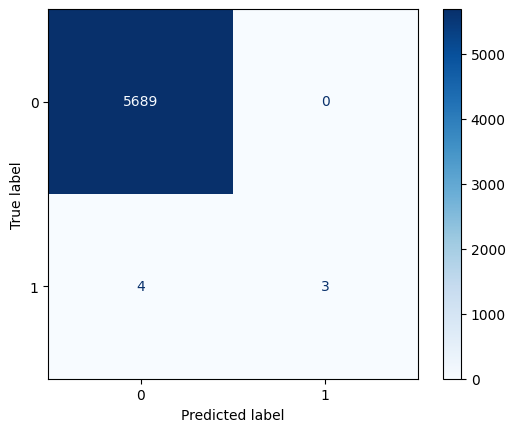

In [171]:
print(classification_report(y_test, baseline_y_pred))
cm_baseline = confusion_matrix(y_test, baseline_y_pred)
disp_baseline = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=baseline_model.classes_)
disp_baseline.plot(cmap=plt.cm.Blues)
plt.show()

In [172]:
class Value(ABC):
    def evaluate(self):
        pass

class Scalar(ABC):
    pass

class Vectorial(ABC):
    pass

In [173]:
@dataclass
class PastValues(Vectorial):
    index: Annotated[int, IntRange(0, n_features-1)]
    lookback: Annotated[int, IntRange(5, 10)]

    def evaluate(self, X_np, i):
        start_index = max(0, i-self.lookback+1)
        values = X_np[start_index: i+1, self.index]
        if len(values) < self.lookback: #if there are not enough past values
            padding = np.zeros(self.lookback - len(values))
            values = np.concatenate((padding, values))
        return values
    def __str__(self):
        return f"past_values({feature_names[self.index]}, {self.lookback})"

In [174]:
@dataclass
class Mean(Scalar):
    arr: Vectorial
    def evaluate(self, X_np, i):
        v = self.arr.evaluate(X_np,i)
        return np.mean(v)
    def __str__(self):
        return f"mean({self.arr})"
    
@dataclass
class Max(Scalar):
    arr: Vectorial
    def evaluate(self, X_np, i):
        v = self.arr.evaluate(X_np,i)
        return np.max(v)
    def __str__(self):
        return f"max({self.arr})"
    
@dataclass
class Min(Scalar):
    arr: Vectorial
    def evaluate(self, X_np, i):
        v = self.arr.evaluate(X_np,i)
        return np.min(v)
    def __str__(self):
        return f"min({self.arr})"


In [175]:
@dataclass #Scalar Features (1)
class ScalarVar(Scalar): 
    index: Annotated[int, IntRange(0,n_features-1)]

    def evaluate(self, X_np, i):
        return X_np[i, self.index]
    
    def __str__(self):
        return feature_names[self.index]

# @dataclass #Vectorial Features ([1,2,3,4])
# class VectorialVar(Vectorial):
#     index: Annotated[int, IntRange(1,2)]
    
#     def evaluate(self, X):
#         return X[self.index]

In [176]:
#scalar -> scalar
@dataclass 
class Add(Scalar):
    right: Scalar
    left: Scalar

    def evaluate(self, X_np, i):
        return self.left.evaluate(X_np,i) + self.right.evaluate(X_np,i)
    
    def __str__(self):
        return f"({self.left} + {self.right})"

@dataclass
class Subtract(Scalar):
    right: Scalar
    left: Scalar

    def evaluate(self, X_np, i):
        return (self.left.evaluate(X_np,i)) - (self.right.evaluate(X_np,i))
    
    def __str__(self):
        return f"({self.left} - {self.right})"
    
@dataclass
class Multiply(Scalar):
    right: Scalar
    left: Scalar

    def evaluate(self, X_np, i):
        return self.left.evaluate(X_np,i) * self.right.evaluate(X_np,i)
    
    def __str__(self):
        return f"({self.left} * {self.right})"

In [177]:
grammar = extract_grammar([PastValues, Mean, Max, Min, ScalarVar, Add, Subtract, Multiply], Scalar)
# grammar = extract_grammar([Add, Subtract, Multiply, ScalarVar], Scalar)
print(f"Grammar: {repr(grammar)}")

Grammar: Grammar<Starting=Scalar,Productions={
Scalar -> Mean(arr: Vectorial)|
	Max(arr: Vectorial)|
	Min(arr: Vectorial)|
	ScalarVar(index: Annotated[int])|
	Add(right: Scalar, left: Scalar)|
	Subtract(right: Scalar, left: Scalar)|
	Multiply(right: Scalar, left: Scalar)

Vectorial -> PastValues(index: Annotated[int], lookback: Annotated[int])
}


In [178]:
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()

def fitness_function(individual: Value): #individual -> expression
    start = time.perf_counter()

    train_feature = [individual.evaluate(X_train_np, i) for i in range(len(X_train_np))]
    test_feature = [individual.evaluate(X_test_np, i) for i in range(len(X_test_np))]

    X_train_new = np.array(train_feature).reshape(-1,1)
    X_test_new = np.array(test_feature).reshape(-1,1)

    features, num_operations = analyse_complexity(individual)

    num_features = len(features)

    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train_new, y_train)
    y_pred = model.predict(X_test_new)

    elapsed = time.perf_counter() - start

    return float(elapsed), f1_score(y_test, y_pred), num_features, num_operations

def analyse_complexity(individual: Value):
    if isinstance(individual, ScalarVar):
        return {individual.index}, 0 #unique feature
    if isinstance(individual, PastValues): 
        return {individual.index}, 0
    
    total_features = set()
    total_operations = 1
    if hasattr(individual, 'left') and hasattr(individual, 'right'):
        left_features, left_operations = analyse_complexity(individual.left)
        right_features, right_operations = analyse_complexity(individual.right)
        total_features.update(left_features)
        total_features.update(right_features)
        total_operations += left_operations + right_operations
    elif hasattr(individual, 'arr'):
        # if isinstance(individual, Mean) and isinstance(individual.arr, PastValues):
            # total_operations += individual.arr.lookback
        arr_features, arr_operations = analyse_complexity(individual.arr)
        total_features.update(arr_features)
        total_operations += arr_operations
    return total_features, total_operations


In [179]:
def lexicase_step():
    return ParallelStep(
        [
            ElitismStep(),
            NoveltyStep(),
            SequenceStep(
                # LexicaseSelection(),
                TournamentSelection(5),
                GenericCrossoverStep(0.01),
                GenericMutationStep(0.9),
            ),
        ],
        weights=[5,5,90]
    )
prob = MultiObjectiveProblem(
    fitness_function=fitness_function,
    minimize=[True, False, True, True],
)
r = NativeRandomSource(123)
alg = GeneticProgramming(
    problem=prob,
    budget=TimeBudget(600),
    population_size=50,
    representation=TreeBasedRepresentation(grammar, MaxDepthDecider(r, grammar, 5)),
    random=r,
    step=lexicase_step(),
    tracker=ProgressTracker(
        prob,
        recorders=[CSVSearchRecorder(
            csv_path='outpupt2.csv', 
            problem=prob, 
            fields={"Eval Time": lambda t,i,p: i.get_fitness(p).fitness_components[0],
                    "F1 Score": lambda t,i,p: i.get_fitness(p).fitness_components[1],
                    "Expression": lambda t, i, p: i.get_phenotype(),
                    'Num Features': lambda t,i,p: i.get_fitness(p).fitness_components[2],
                    'Num Operations': lambda t,i,p: i.get_fitness(p).fitness_components[3]
                    },
            only_record_best_individuals=True)]
    )
    
)

solutions = alg.search()

In [180]:
sorted_solutions = sorted(solutions, key=lambda ind: ind.get_fitness(prob).fitness_components[1], reverse=True)

unique_solutions = []
seen_expressions = set()
for s in sorted_solutions:
    expr = str(s.get_phenotype())
    if expr not in seen_expressions:
        unique_solutions.append(s)
        seen_expressions.add(expr)

In [181]:
for s in unique_solutions[:10]:
    print(f"Expression: {s.get_phenotype()}")
    print(f"Fitness: {s.get_fitness(prob).fitness_components}")

Expression: V17
Fitness: (0.04576130001805723, 0.7142857142857143, 1, 0)
Expression: (V12 + (min(past_values(Amount, 10)) + V10))
Fitness: (0.14326250000158325, 0.6153846153846154, 3, 3)
Expression: (((max(past_values(V12, 7)) - V17) + max(past_values(V27, 6))) * (V12 - mean(past_values(V3, 7))))
Fitness: (0.39095309999538586, 0.5333333333333333, 4, 7)
Expression: ((((V22 + V18) + (Amount + V17)) - V27) + mean(past_values(V10, 5)))
Fitness: (0.21334149996982887, 0.5, 6, 6)
Expression: ((max(past_values(V1, 10)) * ((V14 - V8) - min(past_values(V26, 6)))) + (mean(past_values(V22, 6)) + max(past_values(V17, 9))))
Fitness: (0.47904369997559115, 0.47058823529411764, 6, 9)
Expression: ((min(past_values(V6, 8)) - V17) * min(past_values(V14, 9)))
Fitness: (0.22913450002670288, 0.47058823529411764, 3, 4)
Expression: (V12 - (((V22 - V20) * mean(past_values(V4, 10))) + (max(past_values(V3, 6)) * min(past_values(V27, 7)))))
Fitness: (0.38135380001040176, 0.36363636363636365, 6, 8)
Expression: ((me

In [182]:
top_n_solutions = unique_solutions[:10]

In [183]:
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()
for i, target in enumerate(top_n_solutions):
    expression = target.get_phenotype()
    train_feature_values = [expression.evaluate(X_train_np, i) for i in range(len(X_train_np))]
    test_features_values = [expression.evaluate(X_test_np, i) for i in range(len(X_test_np))]

    
    X_train_fe[f'new_feature_{i}'] = train_feature_values
    X_test_fe[f'new_feature_{i}'] = test_features_values

In [184]:
X_train_fe.head(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,new_feature_0,new_feature_1,new_feature_2,new_feature_3,new_feature_4,new_feature_5,new_feature_6,new_feature_7,new_feature_8,new_feature_9
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.207971,-0.527007,0.072935,0.768505,0.254278,0.064714,-0.621443,0.003346,-1.423771,-0.024160
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.114805,0.560209,0.892087,-1.281142,0.100445,-0.010096,1.192044,0.147263,1.420280,-0.015778
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,1.109969,-0.064325,-0.050927,3.321572,0.910863,0.371017,0.152053,-0.949278,-3.870819,0.954938
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.684093,-0.214775,-1.350684,1.485559,0.650816,-0.187241,0.289979,0.040450,-0.112839,-1.127074
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.237033,0.953219,-0.880489,0.456867,0.564826,-0.173182,0.610548,0.084535,-0.939899,-1.407711


In [185]:
# model_with_new_feature = DecisionTreeClassifier(random_state=42)
model_with_new_feature = RandomForestClassifier(random_state=42)
model_with_new_feature.fit(X_train_fe, y_train)

y_pred_with_new_feature = model_with_new_feature.predict(X_test_fe)
f1_with_new_feature = f1_score(y_test, y_pred_with_new_feature)
print(f1_with_new_feature)
print(model_with_new_feature.feature_importances_)

0.9230769230769231
[0.00960829 0.00501355 0.00956611 0.02274588 0.00274212 0.0124895
 0.00548    0.01054789 0.05909417 0.03870114 0.07861079 0.14741337
 0.00538649 0.04926061 0.00938244 0.0094858  0.07111107 0.00687576
 0.00846368 0.01596037 0.01082362 0.00763741 0.00358131 0.01094447
 0.00758872 0.05657531 0.01065615 0.00934097 0.00870789 0.05349862
 0.09476229 0.00965655 0.03389354 0.02486926 0.0068034  0.00597184
 0.02635048 0.00357651 0.03682262]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5689
           1       1.00      0.86      0.92         7

    accuracy                           1.00      5696
   macro avg       1.00      0.93      0.96      5696
weighted avg       1.00      1.00      1.00      5696



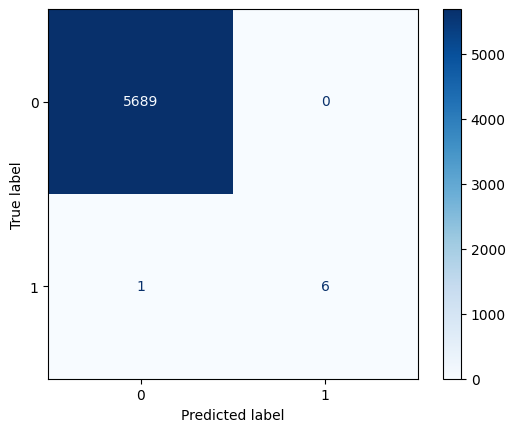

In [186]:
print(classification_report(y_test, y_pred_with_new_feature))
cm = confusion_matrix(y_test, y_pred_with_new_feature)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_with_new_feature.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [187]:
temp_df = X_train_fe.copy()
temp_df['Class'] = y_train

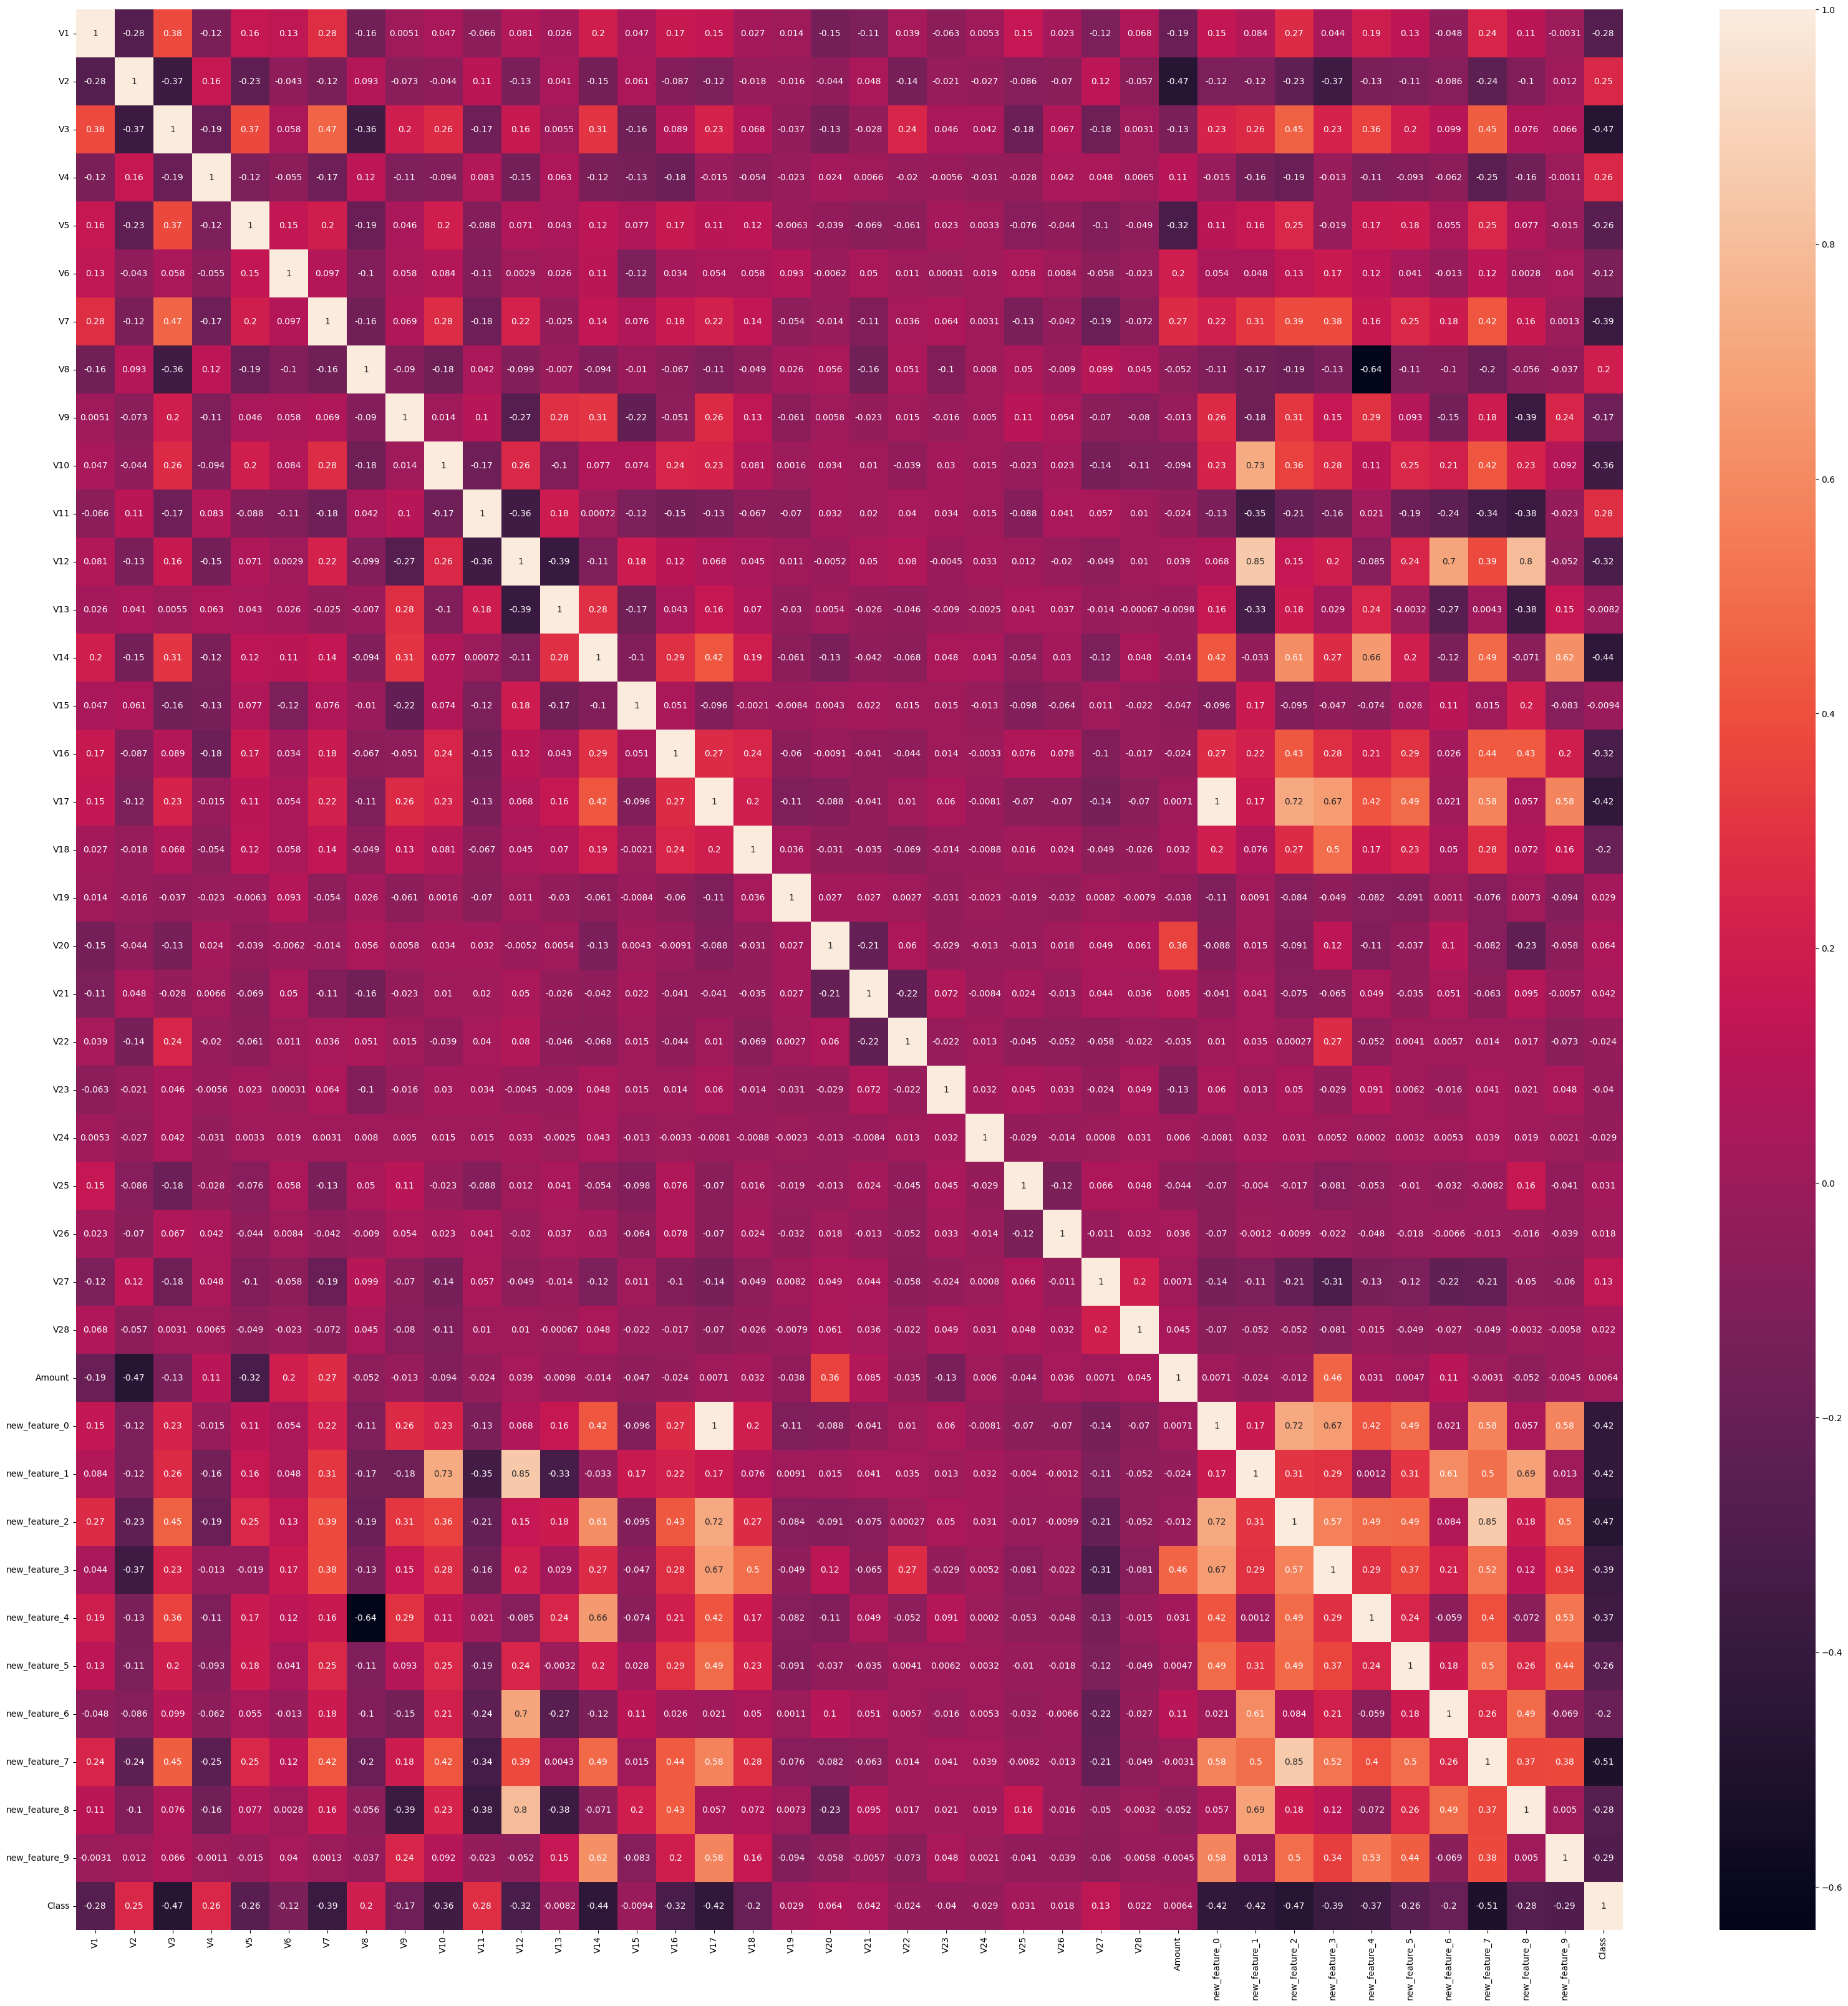

In [188]:
correlation_matrix = temp_df.corr()
plt.figure(figsize=(40,40))
sns.heatmap(correlation_matrix, annot=True)
plt.show()

In [189]:
# test = Max(arr=PastValues(index=feature_names.index('worst fractal dimension'), lockback=4))

# generated_value = [test.evaluate(X_test, i) for i in range(len(X_test))]

# test_df = X_test.copy()
# test_df['generated'] = generated_value
# test_df['target_x'] = y_test
# test_df.head(10)